In [8]:
import os
import pandas as pd
import numpy as np
path = os.path.join( "..", "data", "processed", "accidents_preprocessed.csv")
df = pd.read_csv(path)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.4881 - loss: 1.1105 - val_accuracy: 0.0000e+00 - val_loss: 2.4553
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step - accuracy: 0.6085 - loss: 0.9127 - val_accuracy: 0.0015 - val_loss: 2.1831
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.6179 - loss: 0.8903 - val_accuracy: 0.0011 - val_loss: 2.1854
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.6217 - loss: 0.8812 - val_accuracy: 0.0062 - val_loss: 1.9854
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.6302 - loss: 0.8699 - val_accuracy: 0.0072 - val_loss: 2.0408
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.6334 - loss: 0.8661 - val_accuracy: 0.0106 - val_loss: 2.0460
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.6303 - loss: 0.8622 - val_accuracy: 0.0066 - val_loss: 2.1222
Epoch 8/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - accuracy: 0.6313 - loss: 0.861

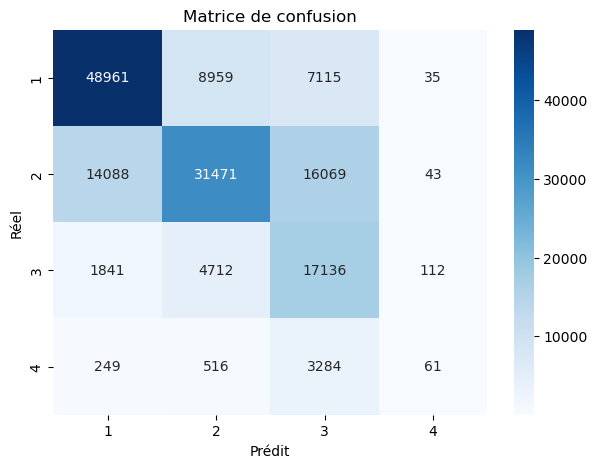

In [ ]:
##################
# DNN avec undersampling 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. Undersampling sur données déjà encodées
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction
y_pred = np.argmax(model.predict(X_test_processed), axis=1)

# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


Epoch 1/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 454us/step - accuracy: 0.6113 - loss: 0.9112 - val_accuracy: 0.0814 - val_loss: 1.5541
Epoch 2/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 448us/step - accuracy: 0.6499 - loss: 0.8252 - val_accuracy: 0.1315 - val_loss: 1.6141
Epoch 3/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 436us/step - accuracy: 0.6544 - loss: 0.8141 - val_accuracy: 0.1431 - val_loss: 1.6250
Epoch 4/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 433us/step - accuracy: 0.6567 - loss: 0.8073 - val_accuracy: 0.1824 - val_loss: 1.4843
Epoch 5/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 430us/step - accuracy: 0.6596 - loss: 0.8002 - val_accuracy: 0.2464 - val_loss: 1.4007
Epoch 6/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 437us/step - accuracy: 0.6614 - loss: 0.7943 - val_accuracy: 0.2272 - val_loss: 1.4318
Epoch 7/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 430us/step - accuracy: 0.6624 - loss: 0.7919 - val_accuracy: 0.2630 - val_loss: 1.3932
Epoch 8/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 434us/step - accuracy: 0.6632 -

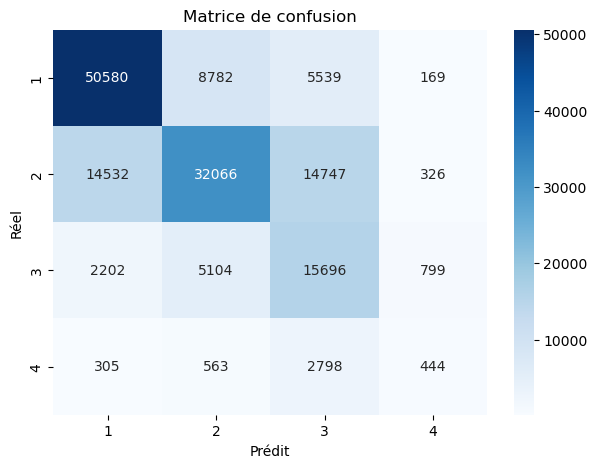

In [ ]:
##################
# DNN avec SMOTETomek 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction
y_pred = np.argmax(model.predict(X_test_processed), axis=1)

# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


Epoch 1/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 466us/step - accuracy: 0.4206 - loss: 1.5495 - val_accuracy: 0.7980 - val_loss: 0.6073
Epoch 2/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 453us/step - accuracy: 0.5130 - loss: 1.3886 - val_accuracy: 0.8238 - val_loss: 0.5322
Epoch 3/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 438us/step - accuracy: 0.5277 - loss: 1.3516 - val_accuracy: 0.9208 - val_loss: 0.3689
Epoch 4/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 442us/step - accuracy: 0.5358 - loss: 1.3278 - val_accuracy: 0.8946 - val_loss: 0.4103
Epoch 5/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 440us/step - accuracy: 0.5439 - loss: 1.3032 - val_accuracy: 0.8862 - val_loss: 0.4144
Epoch 6/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 437us/step - accuracy: 0.5479 - loss: 1.2932 - val_accuracy: 0.8794 - val_loss: 0.4438
Epoch 7/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 440us/step - accuracy: 0.5511 - loss: 1.2803 - val_accuracy: 0.9079 - val_loss: 0.3629
Epoch 8/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 448us/step - accuracy: 0.5534 -

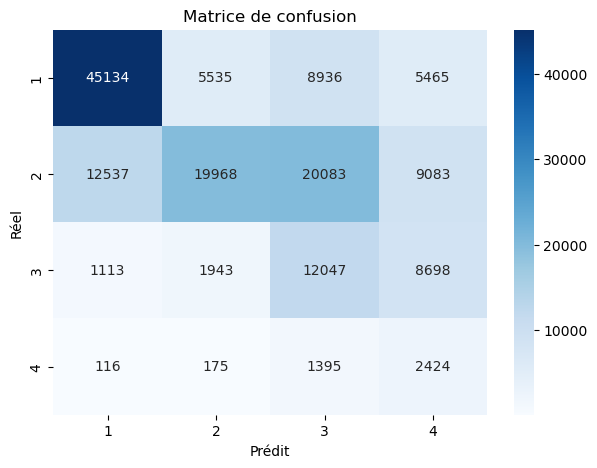

In [ ]:
####################
# DNN avec SMOTETomek et ajustement la fonction de coût (loss) du modèle
####################


import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 6. Calcul des poids de classe
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1, class_weight=class_weights_dict)

# === 8. Prédiction
y_pred = np.argmax(model.predict(X_test_processed), axis=1)

# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


Epoch 1/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 450us/step - accuracy: 0.6112 - loss: 0.9103 - val_accuracy: 0.1191 - val_loss: 1.5039
Epoch 2/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 433us/step - accuracy: 0.6496 - loss: 0.8283 - val_accuracy: 0.1003 - val_loss: 1.7272
Epoch 3/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 446us/step - accuracy: 0.6526 - loss: 0.8183 - val_accuracy: 0.0978 - val_loss: 1.7318
Epoch 4/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 442us/step - accuracy: 0.6560 - loss: 0.8096 - val_accuracy: 0.1481 - val_loss: 1.6024
Epoch 5/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 436us/step - accuracy: 0.6591 - loss: 0.8026 - val_accuracy: 0.1837 - val_loss: 1.5421
Epoch 6/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 432us/step - accuracy: 0.6603 - loss: 0.7972 - val_accuracy: 0.2500 - val_loss: 1.3426
Epoch 7/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 435us/step - accuracy: 0.6621 - loss: 0.7932 - val_accuracy: 0.2619 - val_loss: 1.4017
Epoch 8/10
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 445us/step - accuracy: 0.6643 -

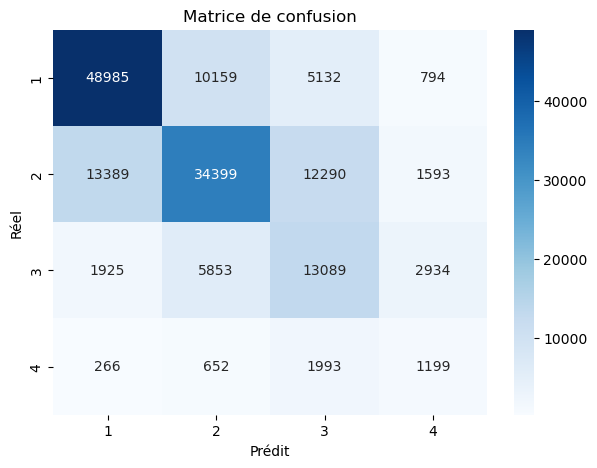

In [13]:
##################
# DNN avec SMOTETomek et ajustement de la probabilité de prédiction pour la classe 4 à 0.2
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction

seuil_classe_4 = 0.2
classe_4_idx = 3  
y_proba = model.predict(X_test_processed)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_proba, axis=1)
y_pred[y_proba[:, classe_4_idx] >= seuil_classe_4] = classe_4_idx



# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

Epoch 1/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 505us/step - accuracy: 0.6366 - loss: 0.8687 - val_accuracy: 0.6184 - val_loss: 1.1026
Epoch 2/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 467us/step - accuracy: 0.6754 - loss: 0.7783 - val_accuracy: 0.7319 - val_loss: 0.8328
Epoch 3/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 461us/step - accuracy: 0.6852 - loss: 0.7574 - val_accuracy: 0.6612 - val_loss: 0.9844
Epoch 4/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 470us/step - accuracy: 0.6889 - loss: 0.7471 - val_accuracy: 0.8119 - val_loss: 0.6558
Epoch 5/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 462us/step - accuracy: 0.6933 - loss: 0.7367 - val_accuracy: 0.8418 - val_loss: 0.5862
Epoch 6/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 466us/step - accuracy: 0.6976 - loss: 0.7283 - val_accuracy: 0.7980 - val_loss: 0.6840
Epoch 7/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 463us/step - accuracy: 0.6993 - loss: 0.7234 - val_accuracy: 0.7645 - val_loss: 0.7535
Epoch 8/100
3533/3533 ━━━━━━━━━━━━━━━━━━━━ 2s 487us/step - accuracy: 

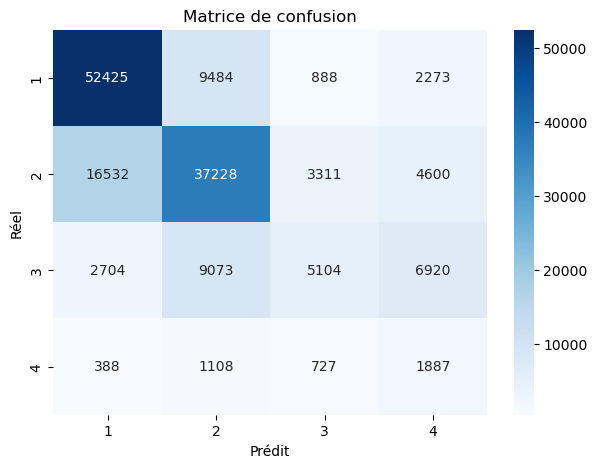

In [ ]:
##################
# DNN avec SMOTETomek et ajustement de la probabilité de prédiction pour la classe 4 à 0.2 et sampling_strategy='minority'
# 1 couche de neurones en plus, 100 epochs 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(sampling_strategy = 'minority', random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=100, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction

seuil_classe_4 = 0.2
classe_4_idx = 3  
y_proba = model.predict(X_test_processed)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_proba, axis=1)
y_pred[y_proba[:, classe_4_idx] >= seuil_classe_4] = classe_4_idx



# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

Epoch 1/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 3s 523us/step - accuracy: 0.5818 - loss: 0.9517 - val_accuracy: 0.0699 - val_loss: 1.5884
Epoch 2/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 481us/step - accuracy: 0.6466 - loss: 0.8331 - val_accuracy: 0.1149 - val_loss: 1.6131
Epoch 3/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 471us/step - accuracy: 0.6508 - loss: 0.8224 - val_accuracy: 0.1752 - val_loss: 1.5610
Epoch 4/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 468us/step - accuracy: 0.6543 - loss: 0.8134 - val_accuracy: 0.1787 - val_loss: 1.5062
Epoch 5/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 501us/step - accuracy: 0.6574 - loss: 0.8067 - val_accuracy: 0.1961 - val_loss: 1.4054
Epoch 6/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 476us/step - accuracy: 0.6588 - loss: 0.8027 - val_accuracy: 0.1705 - val_loss: 1.5165
Epoch 7/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 481us/step - accuracy: 0.6612 - loss: 0.7987 - val_accuracy: 0.2632 - val_loss: 1.2767
Epoch 8/500
4358/4358 ━━━━━━━━━━━━━━━━━━━━ 2s 483us/step - accuracy: 

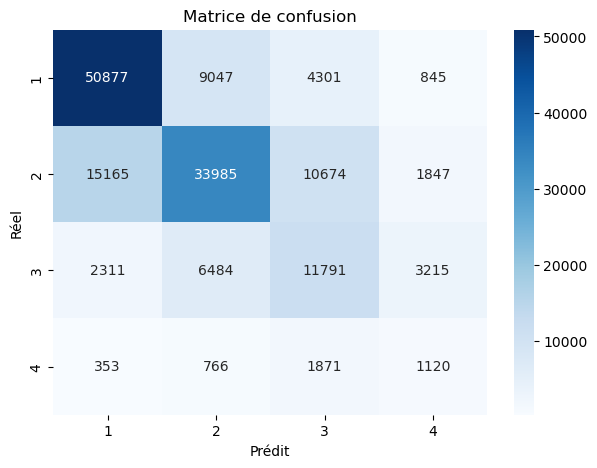

In [17]:
##################
# DNN avec SMOTETomek et ajustement de la probabilité de prédiction pour la classe 4 à 0.2 
# 2 couche de neurones en plus, 500 epochs 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = SMOTETomek(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=500, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction

seuil_classe_4 = 0.2
classe_4_idx = 3  
y_proba = model.predict(X_test_processed)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_proba, axis=1)
y_pred[y_proba[:, classe_4_idx] >= seuil_classe_4] = classe_4_idx



# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

Epoch 1/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - accuracy: 0.4679 - loss: 1.1313 - val_accuracy: 0.0000e+00 - val_loss: 2.2451
Epoch 2/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.5977 - loss: 0.9249 - val_accuracy: 0.0000e+00 - val_loss: 2.2318
Epoch 3/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.6166 - loss: 0.8959 - val_accuracy: 0.0000e+00 - val_loss: 1.9797
Epoch 4/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.6209 - loss: 0.8853 - val_accuracy: 0.0000e+00 - val_loss: 2.2563
Epoch 5/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - accuracy: 0.6231 - loss: 0.8780 - val_accuracy: 0.0000e+00 - val_loss: 2.1307
Epoch 6/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - accuracy: 0.6298 - loss: 0.8659 - val_accuracy: 0.0000e+00 - val_loss: 2.2272
Epoch 7/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.6379 - loss: 0.8540 - val_accuracy: 5.0684e-04 - val_loss: 2.0121
Epoch 8/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step 

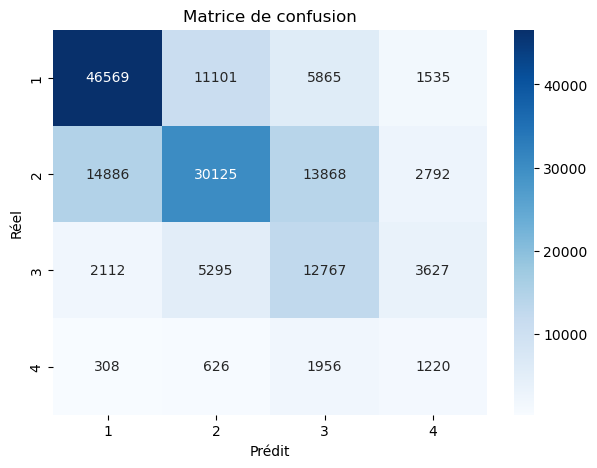

In [18]:
##################
# DNN avec undersampling et ajustement de la probabilité de prédiction pour la classe 4 à 0.2
# 2 couche de neurones en plus, 100 epochs 
##################

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier, KerasRegressor
import warnings
warnings.filterwarnings("ignore")

# === 1. Chargement et split
df = pd.read_csv("../data/processed/accidents_preprocessed.csv")
X = df.drop(columns=["grav"])
y = df["grav"]

# Encodage y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # [1,2,3,4] -> [0,1,2,3]

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, random_state=42)

# === 2. MultiLabelBinarizer sur 'equipements'
mlb = MultiLabelBinarizer()
equip_train = pd.DataFrame(mlb.fit_transform(X_train['equipements']),
                           columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                           index=X_train.index)
equip_test = pd.DataFrame(mlb.transform(X_test['equipements']),
                          columns=[f"eq_{str(c).replace(' ', '_')}" for c in mlb.classes_],
                          index=X_test.index)

# Ajout aux datasets
X_train = pd.concat([X_train.drop(columns="equipements"), equip_train], axis=1)
X_test = pd.concat([X_test.drop(columns="equipements"), equip_test], axis=1)

# === 3. Encodage de "com" avec TargetEncoder
te = TargetEncoder()
X_train["com_encoded"] = te.fit_transform(X_train["com"], y_train)
X_test["com_encoded"] = te.transform(X_test["com"])
X_train.drop(columns="com", inplace=True)
X_test.drop(columns="com", inplace=True)

# === 4. OneHotEncoder sur les autres colonnes
equip_cols = equip_train.columns.tolist()
cols_to_exclude = equip_cols + ['com_encoded']
cols_to_ohe = [col for col in X_train.columns if col not in cols_to_exclude]

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_to_ohe)
], remainder='passthrough')

# === 5. Création du DNN
def create_model(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(len(np.unique(y_train)), activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# On prépare les données pour le DNN
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# === 6. SMOTETomek sur données déjà encodées
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train)

# === 7. Modèle Keras
input_dim = X_train_processed.shape[1]
model = create_model(input_dim)
model.fit(X_resampled, y_resampled, epochs=100, batch_size=128, validation_split=0.2, verbose=1)

# === 8. Prédiction

seuil_classe_4 = 0.2
classe_4_idx = 3  
y_proba = model.predict(X_test_processed)  # shape: (n_samples, n_classes)
y_pred = np.argmax(y_proba, axis=1)
y_pred[y_proba[:, classe_4_idx] >= seuil_classe_4] = classe_4_idx



# === 9. Inverse transform pour afficher y original [1–4]
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# === 10. Résultats
print("📊 Classification report :")
print(classification_report(y_test_labels, y_pred_labels))

cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()